Customer Churn Analysis and Prediction -- Machine Learning Modeling 

This notebook continues the exploratory analysis performed in
`01_exploratory_data_analysis.ipynb`.

The focus here is predictive modeling. Exploratory visualizations and descriptive analysis are not repeated; only the preprocessing required for model training is reproduced.

## Loading and understanding the dataset

In [29]:
# import pandas library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

In [3]:
# loading the dataset
df = pd.read_csv("../data/telco-customer-churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Display some basic info, summary statistics

In [4]:
# Columns and Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Preperation for Modeling

In [15]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"]).copy()

# Remove customer identifier
df = df.drop(columns=["customerID"], errors="ignore")

df.shape

(7032, 20)

In [12]:
# Encode binary categorical variables
binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

binary_mapping = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

df[binary_columns] = df[binary_columns].replace(binary_mapping)

# One-hot encode remaining categorical variables
categorical_columns = df.select_dtypes(include="object").columns.tolist()

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df_encoded.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_14116\1075387331.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace(binary_mapping)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Split the dataset into features and target variable
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X.shape, y.shape

((7032, 30), (7032,))

In [14]:
# Stratified train-test split to maintain the same distribution of the target variable in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (5625, 30)
Test set: (1407, 30)

Training churn distribution:
Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64


## Baseline Model Training and Evaluation

The following models are trained on the original class distribution before applying SMOTE:

- Gaussian Naive Bayes
- Logistic Regression
- Random Forest
- XGBoost

In [16]:
# Scaling the features using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [18]:
# Evaluate models
def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred),
        "Recall": recall_score(y_eval, y_pred),
        "F1 Score": f1_score(y_eval, y_pred),
        "ROC AUC": roc_auc_score(
            y_eval,
            model.predict_proba(X_eval)[:, 1]
        )
    }

In [19]:
# Evaluate baseline models
baseline_results = []

baseline_results.append(
    evaluate_model(
        "Naive Bayes",
        nb_model,
        X_test_scaled,
        y_test
    )
)

baseline_results.append(
    evaluate_model(
        "Logistic Regression",
        lr_model,
        X_test_scaled,
        y_test
    )
)

baseline_results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test,
        y_test
    )
)

baseline_results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_test,
        y_test
    )
)

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.645,0.418,0.864,0.564,0.810
1,Logistic Regression,0.804,0.648,0.575,0.609,0.836
2,Random Forest,0.785,0.619,0.500,0.553,0.815
3,XGBoost,0.767,0.568,0.516,0.541,0.814


### Baseline Model Comparison

The baseline models demonstrate different tradeoffs between identifying churned customers and limiting false-positive predictions.

- **Logistic Regression** provides the strongest overall performance, achieving the highest accuracy (80.4%), F1-score (0.609), and ROC-AUC (0.836).
- **Naive Bayes** achieves the highest recall (86.4%), identifying most customers who actually churned. However, its lower precision (41.8%) indicates that it also generates a relatively large number of false-positive churn predictions.
- **Random Forest** achieves 78.5% accuracy but identifies only 50.0% of actual churners.
- **XGBoost** produces similar performance, with 51.6% recall and an F1-score of 0.541.

Because identifying customers at risk of churn is an important objective, recall is particularly relevant. However, precision and F1-score must also be considered because excessive false-positive predictions could lead to unnecessary retention efforts.

### Baseline Confusion Matrices

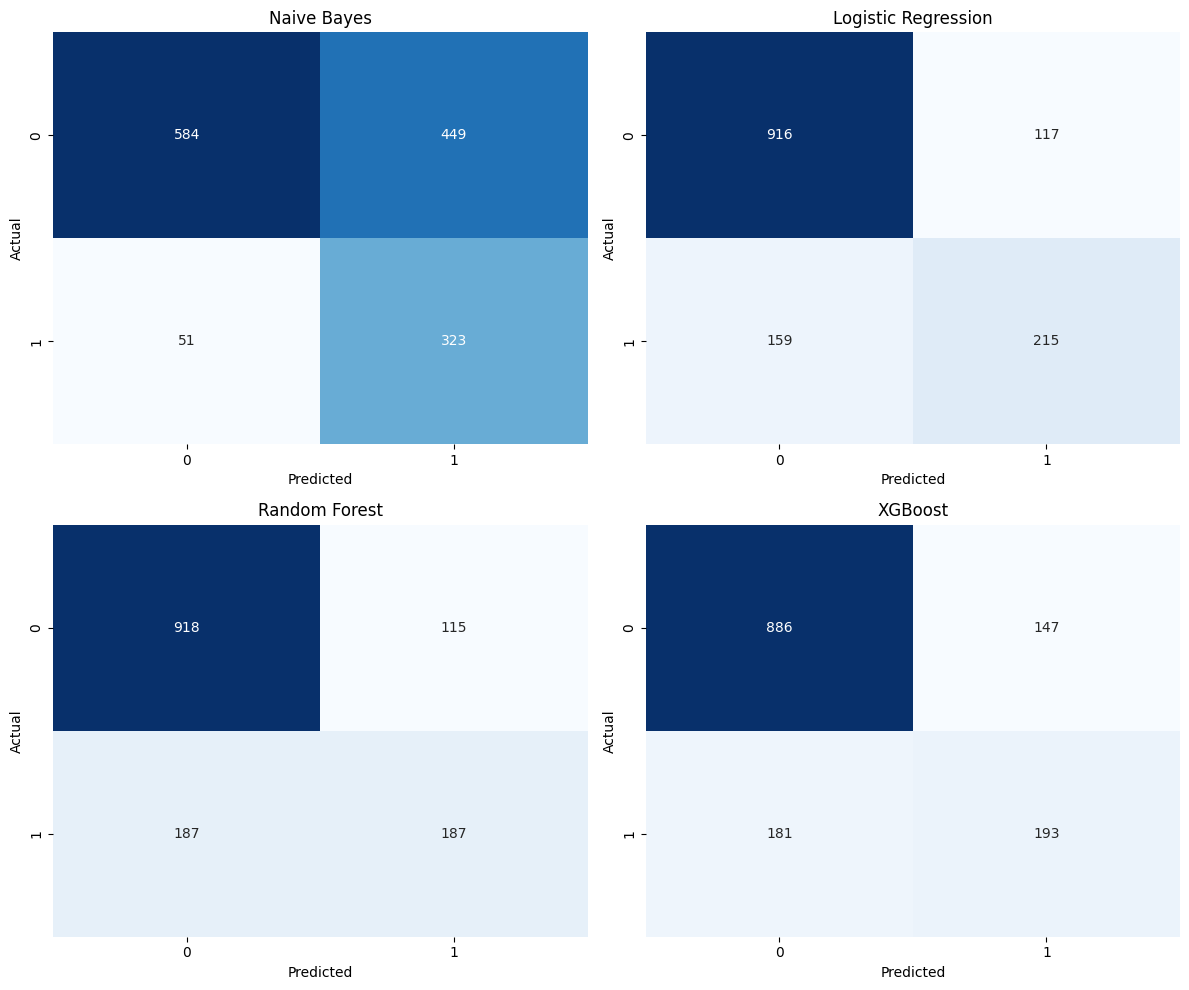

In [20]:
# Confusion Matrices
models_for_confusion = {
    "Naive Bayes": (nb_model, X_test_scaled),
    "Logistic Regression": (lr_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, (model, X_eval)) in zip(
    axes.flatten(),
    models_for_confusion.items()
):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrices highlight the tradeoff between identifying churners and avoiding false-positive predictions.

- **Naive Bayes** detects the largest number of actual churners, with only 51 false negatives, but it also produces a large number of false positives.
- **Logistic Regression** provides the best balance between true-positive detection and false-positive control.
- **Random Forest** is more conservative, producing relatively few false positives but missing more churned customers.
- **XGBoost** shows a similar pattern to Random Forest, with moderate recall and a larger number of false negatives than Logistic Regression.

For a churn-retention use case, false negatives are particularly important because they represent customers who actually churned but were not identified in advance.

## Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) is applied only to the training data to increase representation of the churn class.

The test set remains unchanged so that model performance is evaluated against the original customer distribution. Pipelines are used to ensure that resampling occurs only during model training and does not introduce information from the test set.

In [22]:
# SMOTE Models
smote = SMOTE(random_state=42)

smote_models = {
    "Naive Bayes": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", GaussianNB())
    ]),

    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ]),

    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}

In [23]:
# Fit SMOTE models
for model in smote_models.values():
    model.fit(X_train, y_train)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File

In [24]:
# Evaluate SMOTE models
smote_results = []

for model_name, model in smote_models.items():
    smote_results.append(
        evaluate_model(
            model_name,
            model,
            X_test,
            y_test
        )
    )

smote_results_df = pd.DataFrame(smote_results)

smote_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.655,0.426,0.853,0.568,0.810
1,Logistic Regression,0.732,0.497,0.781,0.608,0.834
2,Random Forest,0.773,0.570,0.599,0.584,0.808
3,XGBoost,0.760,0.545,0.580,0.562,0.800


### SMOTE Model Comparison

Applying SMOTE changes the balance between detecting churned customers and avoiding false-positive predictions.

- **Logistic Regression** shows the largest improvement in recall, increasing from 57.5% to 78.1%. Its F1-score remains almost unchanged, while accuracy and precision decrease as the model identifies more customers as potential churners.
- **Random Forest** improves both recall and F1-score after SMOTE, suggesting that the additional minority-class representation helps the model identify more churned customers.
- **XGBoost** also improves recall and F1-score, although its ROC-AUC decreases slightly.
- **Naive Bayes** changes relatively little because the baseline model already produces very high recall.

Overall, SMOTE improves the ability of several models to detect churners, but this comes with an increased number of false-positive predictions. The appropriate tradeoff depends on the business cost of missing an actual churner compared with unnecessarily targeting a customer for retention.

In [26]:
# Compare baseline and SMOTE results
comparison_df = baseline_results_df.merge(
    smote_results_df,
    on="Model",
    suffixes=("_Baseline", "_SMOTE")
)

comparison_df.round(3)

,Model,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1 Score_Baseline,ROC AUC_Baseline,Accuracy_SMOTE,Precision_SMOTE,Recall_SMOTE,F1 Score_SMOTE,ROC AUC_SMOTE
0,Naive Bayes,0.645,0.418,0.864,0.564,0.810,0.655,0.426,0.853,0.568,0.810
1,Logistic Regression,0.804,0.648,0.575,0.609,0.836,0.732,0.497,0.781,0.608,0.834
2,Random Forest,0.785,0.619,0.500,0.553,0.815,0.773,0.570,0.599,0.584,0.808
3,XGBoost,0.767,0.568,0.516,0.541,0.814,0.760,0.545,0.580,0.562,0.800


In [27]:
# Summary with selected metrics
comparison_summary = comparison_df[
    [
        "Model",
        "Recall_Baseline",
        "Recall_SMOTE",
        "F1 Score_Baseline",
        "F1 Score_SMOTE"
    ]
]

comparison_summary.round(3)

,Model,Recall_Baseline,Recall_SMOTE,F1 Score_Baseline,F1 Score_SMOTE
0,Naive Bayes,0.864,0.853,0.564,0.568
1,Logistic Regression,0.575,0.781,0.609,0.608
2,Random Forest,0.500,0.599,0.553,0.584
3,XGBoost,0.516,0.580,0.541,0.562


In [28]:
# Calculating changes in Recall and F1 Score
comparison_df["Recall Change"] = (
    comparison_df["Recall_SMOTE"]
    - comparison_df["Recall_Baseline"]
)

comparison_df["F1 Change"] = (
    comparison_df["F1 Score_SMOTE"]
    - comparison_df["F1 Score_Baseline"]
)

comparison_df[
    ["Model", "Recall Change", "F1 Change"]
].round(3)

,Model,Recall Change,F1 Change
0,Naive Bayes,-0.011,0.004
1,Logistic Regression,0.206,-0.001
2,Random Forest,0.099,0.031
3,XGBoost,0.064,0.022


### Effect of SMOTE

SMOTE primarily improves the ability of the models to identify churned customers.

- Logistic Regression shows the largest recall improvement, increasing by 20.6 percentage points.
- Random Forest improves both recall and F1-score, producing the strongest balanced improvement after oversampling.
- XGBoost also benefits from SMOTE, although to a smaller degree.
- Naive Bayes changes very little because its baseline model already prioritizes recall.

These results demonstrate that oversampling does not universally improve every metric. Instead, it shifts the balance toward detecting more minority-class customers.

## Hyperparameter Tuning

Hyperparameter tuning is performed using cross-validation on pipelines that contain SMOTE. This ensures that synthetic observations are generated only within the training folds rather than before cross-validation, reducing the risk of data leakage.

F1-score is used as the optimization metric to balance precision and recall.

In [30]:
# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [31]:
# Hyperparameter tuning for Logistic Regression with SMOTE
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=smote_models["Logistic Regression"],
    param_grid=lr_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1
)

lr_grid.fit(X_train, y_train)

print("Best parameters:", lr_grid.best_params_)
print("Best CV F1:", round(lr_grid.best_score_, 3))

Best parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best CV F1: 0.631


In [32]:
# Hyperparameter tuning for Random Forest with SMOTE
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=smote_models["Random Forest"],
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV F1:", round(rf_grid.best_score_, 3))

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.623


In [33]:
# Hyperparameter tuning for XGBoost with SMOTE
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=smote_models["XGBoost"],
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV F1:", round(xgb_grid.best_score_, 3))

Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV F1: 0.626


### Tuned Model Evaluation on the Test Set

In [34]:
# Evaluate tuned models
tuned_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

tuned_results = []

for model_name, model in tuned_models.items():
    tuned_results.append(
        evaluate_model(
            model_name,
            model,
            X_test,
            y_test
        )
    )

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.736,0.502,0.775,0.609,0.834
1,Random Forest,0.767,0.549,0.684,0.610,0.826
2,XGBoost,0.750,0.522,0.698,0.597,0.824


In [35]:
# Compare tuned models with SMOTE models
tuned_vs_smote = smote_results_df.merge(
    tuned_results_df,
    on="Model",
    suffixes=("_SMOTE", "_Tuned")
)

tuned_vs_smote.round(3)

,Model,Accuracy_SMOTE,Precision_SMOTE,Recall_SMOTE,F1 Score_SMOTE,ROC AUC_SMOTE,Accuracy_Tuned,Precision_Tuned,Recall_Tuned,F1 Score_Tuned,ROC AUC_Tuned
0,Logistic Regression,0.732,0.497,0.781,0.608,0.834,0.736,0.502,0.775,0.609,0.834
1,Random Forest,0.773,0.570,0.599,0.584,0.808,0.767,0.549,0.684,0.610,0.826
2,XGBoost,0.760,0.545,0.580,0.562,0.800,0.750,0.522,0.698,0.597,0.824


In [36]:
# Summary with selected metrics
tuned_summary = tuned_vs_smote[
    [
        "Model",
        "Recall_SMOTE",
        "Recall_Tuned",
        "F1 Score_SMOTE",
        "F1 Score_Tuned",
        "ROC AUC_SMOTE",
        "ROC AUC_Tuned"
    ]
]

tuned_summary.round(3)

,Model,Recall_SMOTE,Recall_Tuned,F1 Score_SMOTE,F1 Score_Tuned,ROC AUC_SMOTE,ROC AUC_Tuned
0,Logistic Regression,0.781,0.775,0.608,0.609,0.834,0.834
1,Random Forest,0.599,0.684,0.584,0.610,0.808,0.826
2,XGBoost,0.580,0.698,0.562,0.597,0.800,0.824


### Interpretation

Hyperparameter tuning improves the performance of the tree-based models, particularly Random Forest and XGBoost.

- **Logistic Regression** changes very little after tuning, suggesting that the untuned SMOTE model was already close to its optimal configuration. It retains the highest recall among the tuned models at 77.5%.
- **Random Forest** benefits substantially from tuning. Recall increases from 59.9% to 68.4%, F1-score rises from 0.584 to 0.610, and ROC-AUC improves from 0.808 to 0.826.
- **XGBoost** also improves considerably, with recall increasing from 58.0% to 69.8% and F1-score increasing from 0.562 to 0.597.

Among the tuned models, Random Forest provides the strongest balance between precision and recall, while Logistic Regression remains preferable when maximizing churn detection is the primary objective.

### Tuned Model Confusion Matrices

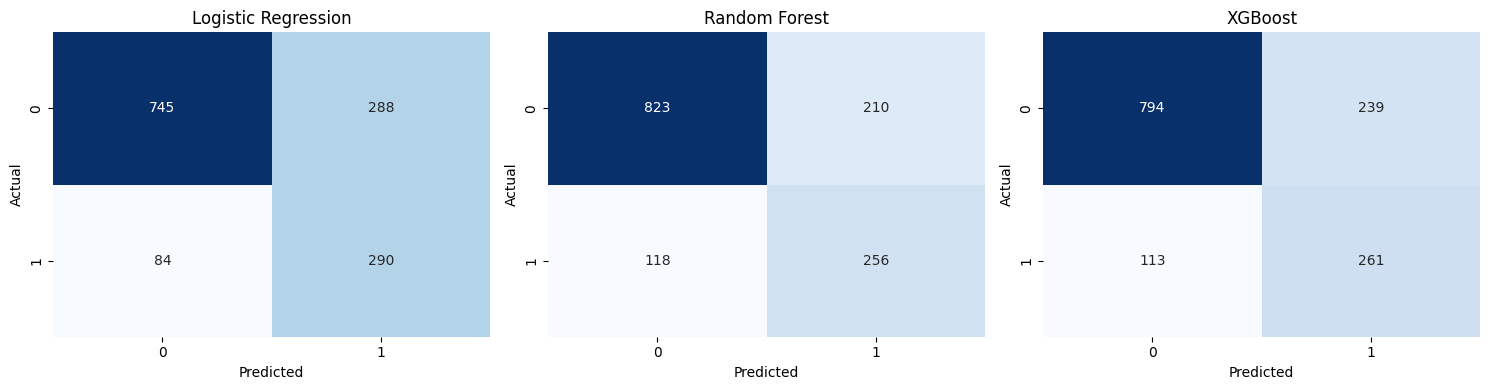

In [37]:
# Calculating changes in Recall, F1 Score, and ROC AUC
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(
    axes,
    tuned_models.items()
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Final Model Comparison

In [38]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Baseline Recall": [
        baseline_results_df.loc[
            baseline_results_df["Model"] == "Logistic Regression",
            "Recall"
        ].values[0],
        baseline_results_df.loc[
            baseline_results_df["Model"] == "Random Forest",
            "Recall"
        ].values[0],
        baseline_results_df.loc[
            baseline_results_df["Model"] == "XGBoost",
            "Recall"
        ].values[0]
    ],

    "SMOTE Recall": [
        smote_results_df.loc[
            smote_results_df["Model"] == "Logistic Regression",
            "Recall"
        ].values[0],
        smote_results_df.loc[
            smote_results_df["Model"] == "Random Forest",
            "Recall"
        ].values[0],
        smote_results_df.loc[
            smote_results_df["Model"] == "XGBoost",
            "Recall"
        ].values[0]
    ],

    "Tuned Recall": [
        tuned_results_df.loc[
            tuned_results_df["Model"] == "Logistic Regression",
            "Recall"
        ].values[0],
        tuned_results_df.loc[
            tuned_results_df["Model"] == "Random Forest",
            "Recall"
        ].values[0],
        tuned_results_df.loc[
            tuned_results_df["Model"] == "XGBoost",
            "Recall"
        ].values[0]
    ],

    "Baseline F1": [
        baseline_results_df.loc[
            baseline_results_df["Model"] == "Logistic Regression",
            "F1 Score"
        ].values[0],
        baseline_results_df.loc[
            baseline_results_df["Model"] == "Random Forest",
            "F1 Score"
        ].values[0],
        baseline_results_df.loc[
            baseline_results_df["Model"] == "XGBoost",
            "F1 Score"
        ].values[0]
    ],

    "SMOTE F1": [
        smote_results_df.loc[
            smote_results_df["Model"] == "Logistic Regression",
            "F1 Score"
        ].values[0],
        smote_results_df.loc[
            smote_results_df["Model"] == "Random Forest",
            "F1 Score"
        ].values[0],
        smote_results_df.loc[
            smote_results_df["Model"] == "XGBoost",
            "F1 Score"
        ].values[0]
    ],

    "Tuned F1": [
        tuned_results_df.loc[
            tuned_results_df["Model"] == "Logistic Regression",
            "F1 Score"
        ].values[0],
        tuned_results_df.loc[
            tuned_results_df["Model"] == "Random Forest",
            "F1 Score"
        ].values[0],
        tuned_results_df.loc[
            tuned_results_df["Model"] == "XGBoost",
            "F1 Score"
        ].values[0]
    ]
})

final_comparison.round(3)

,Model,Baseline Recall,SMOTE Recall,Tuned Recall,Baseline F1,SMOTE F1,Tuned F1
0,Logistic Regression,0.575,0.781,0.775,0.609,0.608,0.609
1,Random Forest,0.500,0.599,0.684,0.553,0.584,0.610
2,XGBoost,0.516,0.580,0.698,0.541,0.562,0.597


### Final Model Interpretation

The tuned models demonstrate different tradeoffs between churn detection and false-positive control.

- **Logistic Regression** identifies the largest number of churned customers, correctly detecting 290 of 374 churners. Its higher recall comes at the cost of more false-positive predictions.
- **Random Forest** detects fewer churners than Logistic Regression but produces substantially fewer false positives, resulting in the strongest overall F1-score.
- **XGBoost** provides performance between the other two models, with slightly higher recall than Random Forest but a lower F1-score.

The preferred model therefore depends on the retention strategy. If failing to identify a churner is especially costly, Logistic Regression is attractive because of its higher recall. If a better balance between detecting churners and limiting unnecessary retention interventions is preferred, tuned Random Forest is the stronger choice.

## Model Selection

Based on the final test-set evaluation, **tuned Random Forest** is selected as the best balanced model.

It achieves:

- **Accuracy:** 76.7%
- **Precision:** 54.9%
- **Recall:** 68.4%
- **F1-score:** 0.610
- **ROC-AUC:** 0.826

Although tuned Logistic Regression achieves a higher recall of 77.5%, Random Forest produces the highest F1-score while maintaining better precision and accuracy. This makes it a practical choice when both identifying at-risk customers and limiting unnecessary retention interventions are important.

For a business scenario where maximizing churn detection is the overriding priority, Logistic Regression remains a viable alternative.

## Conclusion

This modeling analysis compared Naive Bayes, Logistic Regression, Random Forest, and XGBoost for predicting customer churn.

The baseline models showed that Logistic Regression provided the strongest overall initial performance, while Naive Bayes achieved the highest recall but generated many false positives.

Applying SMOTE improved churn-class detection for Logistic Regression, Random Forest, and XGBoost. Hyperparameter tuning further improved the tree-based models, with Random Forest achieving the strongest balance of precision and recall.

The results also demonstrate that model selection should not be based on accuracy alone. In churn prediction, the relative cost of missed churners and false-positive retention efforts should guide the final choice of model and decision threshold.